# SI — Contributor definition

Produces `figures/fig_SI2.pdf`: the cumulative all-contributor count against
the cumulative focal-contributor count, with the linear fit whose slope is the
effective rescaling factor between the two conventions.

Requires the granularity cache built by `si_build_granularity.ipynb`.


In [1]:
# Repository bootstrap.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"               # derived data, auto-generated
FIGURE_DIR = REPO_ROOT / "figures"               # manuscript figures, versioned
GRANULARITY_DIR = OUTPUT_DIR / "granularity"     # built by si_build_granularity

# Papers without keywords cannot produce a combination novelty and are excluded
# from the event process. This is the convention of the revised manuscript.
filter_empty_keywords = True


## Imports and style


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from plot_style import apply_si_style, DIST_COLORS, SI_DATA_LW, SI_FIT_LW

apply_si_style()
colors_dist = dict(DIST_COLORS)

pd.set_option("display.max_columns", 60)


## Load the two contributor conventions

`Dw_first` counts each event's focal contributor only, `Dw_all` counts every
contributor. Both are already accumulated event by event in the granularity
cache; the table below reports their end-of-period values and their ratio.


In [3]:
from analysis_utils import load_granularity_datasets
from utils import branching_models

shared = load_granularity_datasets(
    GRANULARITY_DIR,
    filter_empty_keywords=filter_empty_keywords,
)

datasets = {}
for name, data in shared.items():
    events = data["events"][[
        "date", "date_ord", "tau", "year", "t", "D_combo",
        "Dw_first", "Dw_all", "n_authors_event", "n_tokens_event",
    ]].rename(columns={"D_combo": "D"})
    annual = data["annual"][[
        "year", "tau", "delta_t", "D_combo", "Dw_first", "Dw_all",
        "active_first_authors", "active_all_authors", "mean_authors_per_event",
    ]].rename(columns={"D_combo": "D"})
    datasets[name] = {"events": events, "annual": annual}

display(pd.DataFrame([{
    "dataset": name,
    "events": len(d["events"]),
    "final_Dw_first": int(d["events"]["Dw_first"].iloc[-1]),
    "final_Dw_all": int(d["events"]["Dw_all"].iloc[-1]),
    "all_over_first_final": float(
        d["events"]["Dw_all"].iloc[-1] / d["events"]["Dw_first"].iloc[-1]),
    "mean_authors_per_event": float(d["annual"]["mean_authors_per_event"].mean()),
} for name, d in datasets.items()]))


,dataset,events,final_Dw_first,final_Dw_all,all_over_first_final,mean_authors_per_event
0,patents,1431653,893828,1989732,2.226079,2.822449
1,papers,5193236,1333013,3045970,2.285026,4.198097


## The figure

One panel per dataset, on log-log axes. The fitted slope is the effective
rescaling factor: note that it is *not* the mean team size, because
contributors recur across events.


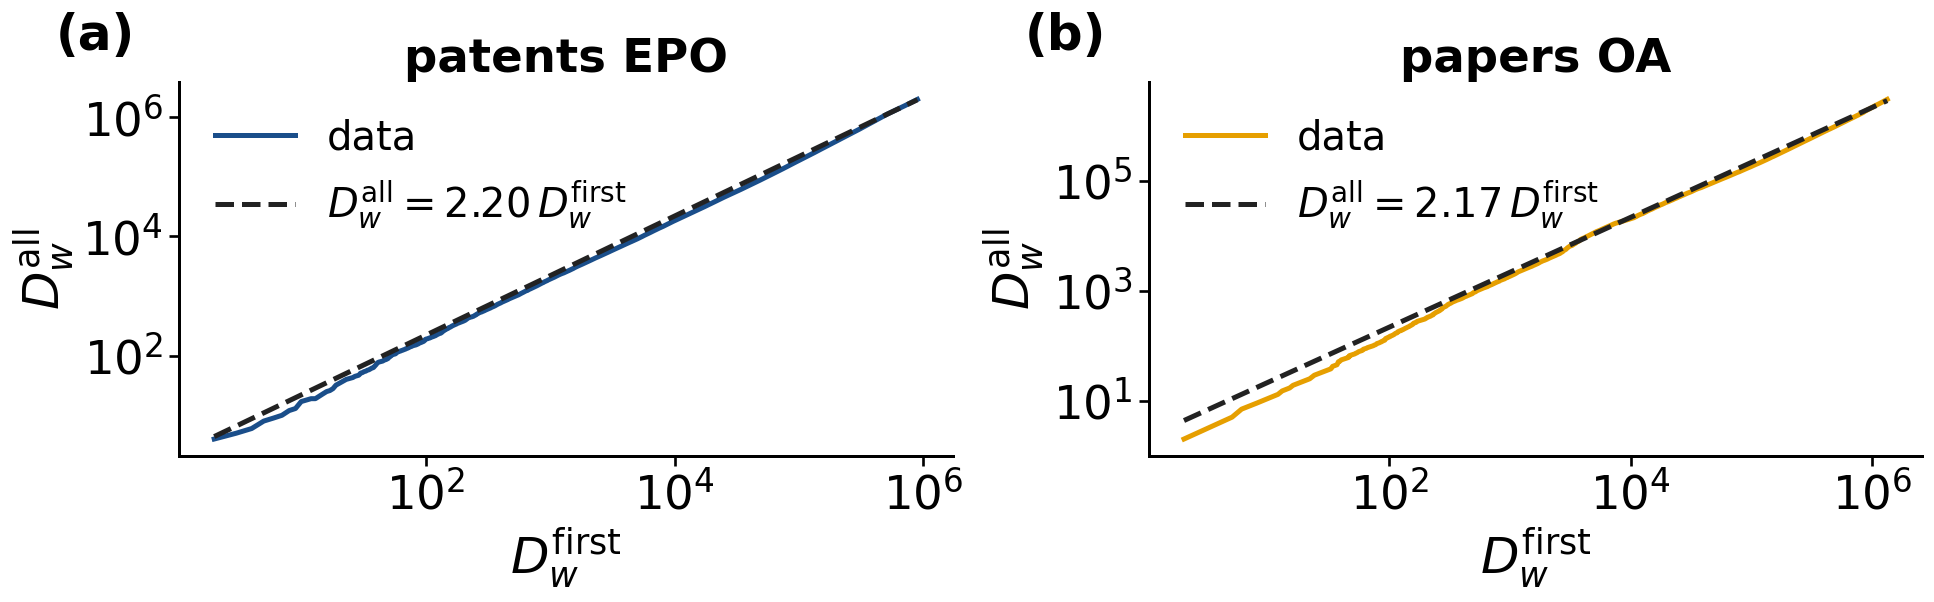

figure -> figures/fig_SI2.pdf
patents {'linear_slope': 2.1974, 'power_beta': 1.0633, 'power_a': 0.9375}
papers {'linear_slope': 2.1701, 'power_beta': 1.0653, 'power_a': 0.8682}


In [4]:
# Final SI figure for the contributor-definition robustness check.
# 1x2 panel: cumulative all-contributor count against cumulative
# focal-contributor count, with the linear fit whose slope is the effective
# rescaling factor between the two conventions.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_TITLE = {"patents": "patents EPO", "papers": "papers OA"}
DATASET_COLOR = {"patents": colors_dist["patents"], "papers": colors_dist["papers"]}

fig, axes = plt.subplots(1, 2, figsize=(16, 4.9), constrained_layout=True)
contributor_fits = {}

for col_idx, name in enumerate(["patents", "papers"]):
    events = datasets[name]["events"]
    x_vals = events["Dw_first"].to_numpy(dtype=float)
    y_vals = events["Dw_all"].to_numpy(dtype=float)
    fits = branching_models(x_vals, y_vals).set_index("model")
    linear_fit = fits.loc["linear: b * D"]
    power_fit = fits.loc["power: a * D^beta"]
    contributor_fits[name] = {
        "linear_slope": float(linear_fit["b"]),
        "power_beta": float(power_fit["beta"]),
        "power_a": float(power_fit["a"]),
    }

    # Log-log axes: the near-linear relation spans several decades.
    positive = (x_vals > 0) & (y_vals > 0)
    idx = np.unique(np.round(np.logspace(
        0, np.log10(int(positive.sum()) - 1), 1500)).astype(int))
    x_plot = x_vals[positive][idx]
    y_plot = y_vals[positive][idx]
    ax = axes[col_idx]
    ax.loglog(x_plot, y_plot, lw=SI_DATA_LW, color=DATASET_COLOR[name],
              label="data")
    ax.loglog(x_plot, linear_fit["b"] * x_plot, ls="--", lw=SI_FIT_LW,
              color=colors_dist["reference"],
              label=r"$D_w^{\mathrm{all}} = %.2f\,D_w^{\mathrm{first}}$" % linear_fit["b"])
    ax.set_xlabel(r"$D_w^{\mathrm{first}}$")
    ax.set_ylabel(r"$D_w^{\mathrm{all}}$")
    ax.set_title(DATASET_TITLE[name], fontsize=28, fontweight="bold")
    ax.legend(loc="upper left", frameon=False, fontsize=24)
    ax.text(-0.16, 1.06, "(a)" if col_idx == 0 else "(b)", transform=ax.transAxes,
            va="bottom", ha="left", fontsize=30, fontweight="bold")

fig.savefig(FIGURE_DIR / "fig_SI2.pdf", format="pdf", facecolor="white")
plt.show()
print("figure ->", (FIGURE_DIR / "fig_SI2.pdf").relative_to(REPO_ROOT))
for name, values in contributor_fits.items():
    print(name, {k: round(v, 4) for k, v in values.items()})
